# Loan Default Risk Classification for Banking

## Problem Statement
The objective of this project is to predict whether a loan applicant is likely to default based on financial, demographic, and credit-related information.

Financial institutions face significant risks when approving loans for high-risk customers. Therefore, machine learning techniques can help identify potential defaulters and support better lending decisions.

## Project Objectives
- Perform data cleaning and preprocessing
- Handle missing values and class imbalance
- Conduct exploratory data analysis (EDA)
- Engineer meaningful financial risk features
- Prepare data for machine learning models
- Optimize recall to reduce risky loan approvals
- Use explainable AI techniques such as SHAP for interpretability

## Dataset Information
This project uses a modified version of the Home Credit Default Risk dataset.

Source:
Mendeley Data Repository

Original Dataset:
Kaggle Home Credit Default Risk Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
import pandas as pd

df = pd.read_csv("/content/application_train new.csv")

print(df.shape)
df.head()

/tmp/ipykernel_3203/1324418112.py:3: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("/content/application_train new.csv")


(307511, 123)


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


# Stage 2 — Data Understanding

In [8]:
print(df.info())

print("\nMissing Values:\n")
print(df.isnull().sum())

print("\nTarget Distribution:\n")
print(df['TARGET'].value_counts())

print("\nTarget Percentage:\n")
print(df['TARGET'].value_counts(normalize=True))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Columns: 123 entries, SK_ID_CURR to AMT_REQ_CREDIT_BUREAU_YEAR
dtypes: float64(65), int64(41), object(17)
memory usage: 288.6+ MB
None

Missing Values:

SK_ID_CURR                        0
TARGET                            0
NAME_CONTRACT_TYPE                0
CODE_GENDER                       0
FLAG_OWN_CAR                      0
                              ...  
AMT_REQ_CREDIT_BUREAU_DAY     41519
AMT_REQ_CREDIT_BUREAU_WEEK    41519
AMT_REQ_CREDIT_BUREAU_MON     41519
AMT_REQ_CREDIT_BUREAU_QRT     41519
AMT_REQ_CREDIT_BUREAU_YEAR    41519
Length: 123, dtype: int64

Target Distribution:

TARGET
0    282686
1     24825
Name: count, dtype: int64

Target Percentage:

TARGET
0    0.919271
1    0.080729
Name: proportion, dtype: float64


# --- STAGE 3: DATA CLEANING ---

In [9]:
missing_values = df.isnull().sum()

missing_values = missing_values[missing_values > 0]

missing_values.sort_values(ascending=False).head(20)

,0
COMMONAREA_MEDI,214865
COMMONAREA_MODE,214865
COMMONAREA_AVG,214865
NONLIVINGAPARTMENTS_MODE,213514
NONLIVINGAPARTMENTS_MEDI,213514
NONLIVINGAPARTMENTS_AVG,213514
FONDKAPREMONT_MODE,210295
LIVINGAPARTMENTS_AVG,210199
LIVINGAPARTMENTS_MEDI,210199
LIVINGAPARTMENTS_MODE,210199


In [10]:
threshold = len(df) * 0.5

df = df.dropna(thresh=threshold, axis=1)

print("New Shape:", df.shape)

New Shape: (307511, 82)


Columns with excessive missing values were removed to improve data quality and reduce noise.

In [13]:
# Fill numeric columns with median
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

# Fill categorical columns with mode
categorical_cols = df.select_dtypes(include=['object']).columns

for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

print("Remaining Missing Values:", df.isnull().sum().sum())

Remaining Missing Values: 0


# Stage 4 — EDA Visualizations

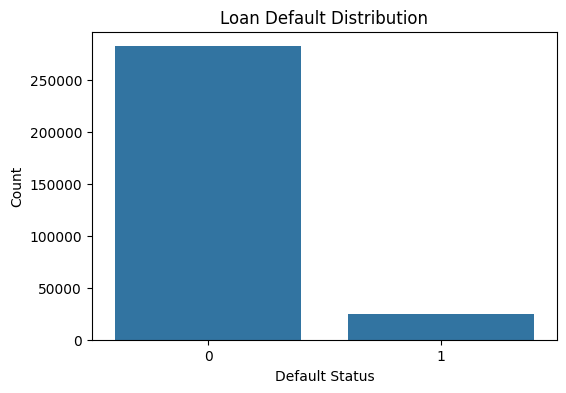

In [14]:
plt.figure(figsize=(6,4))

sns.countplot(x='TARGET', data=df)

plt.title("Loan Default Distribution")
plt.xlabel("Default Status")
plt.ylabel("Count")

plt.show()

income distribution

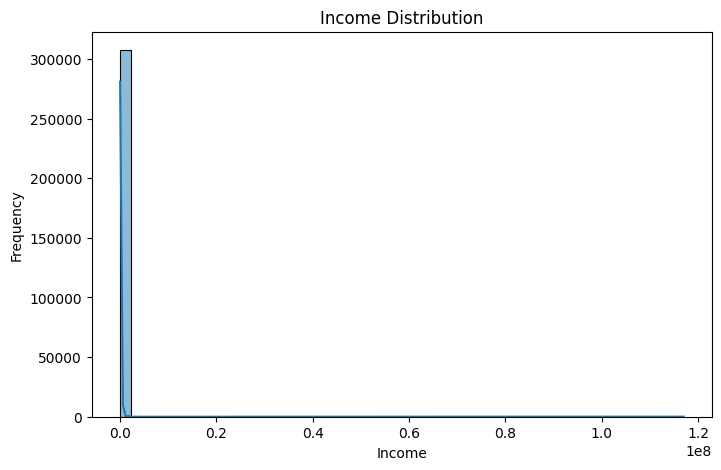

In [15]:
plt.figure(figsize=(8,5))

sns.histplot(df['AMT_INCOME_TOTAL'], bins=50, kde=True)

plt.title("Income Distribution")
plt.xlabel("Income")
plt.ylabel("Frequency")

plt.show()

income vs default risk properly using a boxplot.

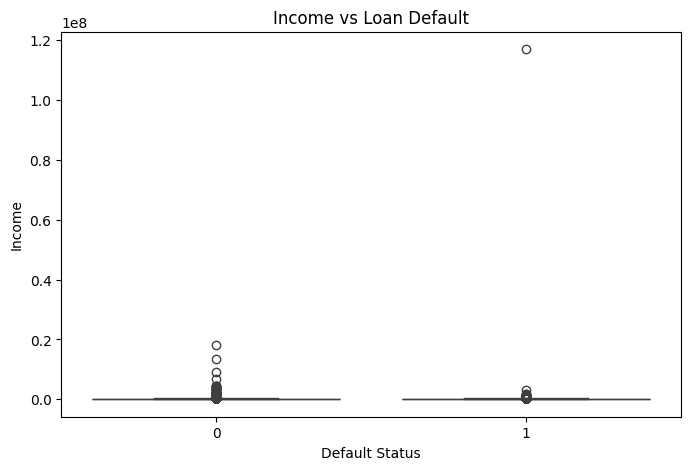

In [16]:
plt.figure(figsize=(8,5))

sns.boxplot(x='TARGET', y='AMT_INCOME_TOTAL', data=df)

plt.title("Income vs Loan Default")
plt.xlabel("Default Status")
plt.ylabel("Income")

plt.show()

The income feature contains significant outliers and a highly skewed distribution. Most applicants fall within a lower income range, while a few extreme values stretch the distribution.

Credit Score vs Default

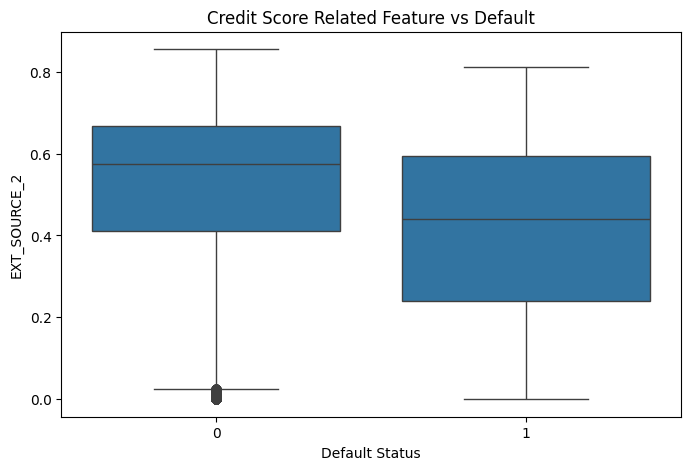

In [17]:
plt.figure(figsize=(8,5))

sns.boxplot(x='TARGET', y='EXT_SOURCE_2', data=df)

plt.title("Credit Score Related Feature vs Default")
plt.xlabel("Default Status")
plt.ylabel("EXT_SOURCE_2")

plt.show()

Applicants with lower EXT_SOURCE_2 values show a higher likelihood of loan default, indicating that external credit-related scores are strong predictors of repayment risk.

Correlation Heatmap

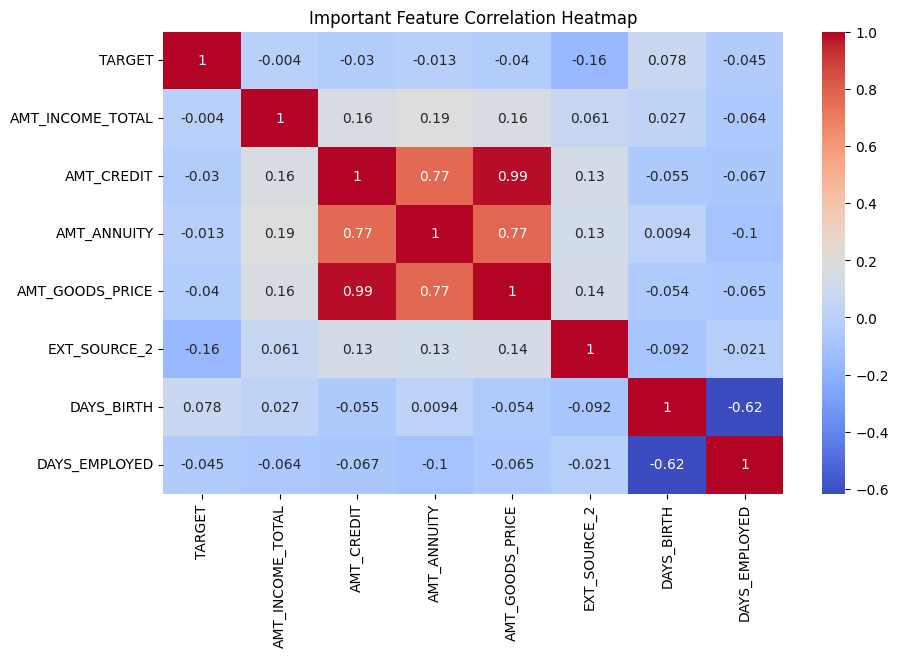

In [19]:
important_features = [
    'TARGET',
    'AMT_INCOME_TOTAL',
    'AMT_CREDIT',
    'AMT_ANNUITY',
    'AMT_GOODS_PRICE',
    'EXT_SOURCE_2',
    'DAYS_BIRTH',
    'DAYS_EMPLOYED'
]

plt.figure(figsize=(10,6))

corr_matrix = df[important_features].corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')

plt.title("Important Feature Correlation Heatmap")

plt.show()

# Stage 5 — Feature Engineering & Selection

In [20]:
df['LOAN_TO_INCOME_RATIO'] = df['AMT_CREDIT'] / df['AMT_INCOME_TOTAL']

df['LOAN_TO_INCOME_RATIO'].head()

,LOAN_TO_INCOME_RATIO
0,2.007889
1,4.790750
2,2.000000
3,2.316167
4,4.222222


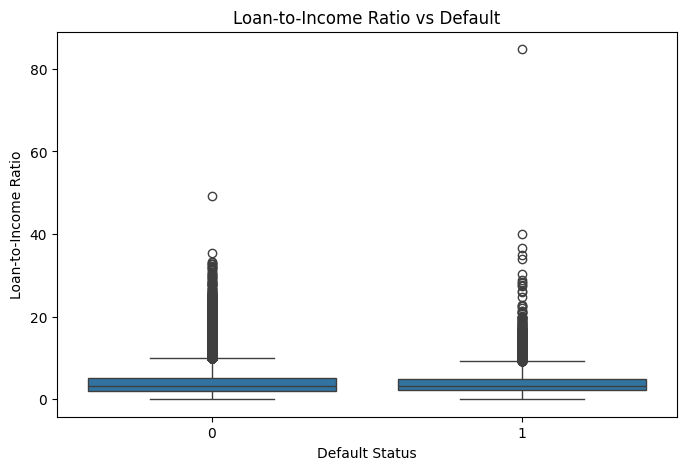

In [21]:
plt.figure(figsize=(8,5))

sns.boxplot(x='TARGET', y='LOAN_TO_INCOME_RATIO', data=df)

plt.title("Loan-to-Income Ratio vs Default")
plt.xlabel("Default Status")
plt.ylabel("Loan-to-Income Ratio")

plt.show()

Do defaulters generally have higher loan burden compared to income?

In [22]:
selected_features = [
    'AMT_INCOME_TOTAL',
    'AMT_CREDIT',
    'AMT_ANNUITY',
    'AMT_GOODS_PRICE',
    'EXT_SOURCE_2',
    'DAYS_BIRTH',
    'DAYS_EMPLOYED',
    'LOAN_TO_INCOME_RATIO'
]

X = df[selected_features]

y = df['TARGET']

print(X.shape)
print(y.shape)

(307511, 8)
(307511,)


# train-test split

In [23]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)

Training Shape: (246008, 8)
Testing Shape: (61503, 8)


In [24]:
train_df = X_train.copy()
train_df['TARGET'] = y_train

test_df = X_test.copy()
test_df['TARGET'] = y_test

train_df.to_csv("train_data.csv", index=False)
test_df.to_csv("test_data.csv", index=False)

print("Train and test CSV files created successfully.")

Train and test CSV files created successfully.
